In [2]:
# Import Necessary PyTorch Modules
import torch
from torch import nn
import matplotlib.pyplot as plt


In [3]:
# create known parameter

weight = 0.7
bias   = 0.3

# Create a range of numbers

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [6]:
# Split Data in train and test part

train_split = int(0.8 * len(X))
#train_split
X_train,y_train = X[:train_split], y[:train_split]
X_test , y_test = X[train_split:] , y [train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [8]:
# Create a Linear Regression Model

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # using nn.Linear() for creating the model parameters/also called: linear transform
        self.linear_layer = nn.Linear(in_features=1,out_features=1)

    def forward(self,x: torch.Tensor)-> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [9]:
X_train[:5] , y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [13]:
# Create a Instance of the Linear Regression Mode
model_1 = LinearRegressionModelV2()
model_1, model_1.parameters()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 <generator object Module.parameters at 0x112aac220>)

In [12]:
# Setup the loss function 
loss_fn = nn.L1Loss()
# Setup the optimizer 
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.01)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [22]:
# Create a set a random seed
RANDOM_SEED=42
torch.manual_seed(RANDOM_SEED)

# set the value of epoch
epochs = 200

for epoch in range(epochs):
    model_1.train()

    #1. Forward Pass
    y_pred = model_1(X_train)

    # Calculate the loss
    loss = loss_fn(y_pred,y_train)

    # Optimizer
    optimizer.zero_grad()

    # Perform Backpropagation
    loss.backward()

    # Optimizer Step 
    optimizer.step()

    #print(f"Loss: ",loss)

    # Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)

        test_loss = loss_fn(test_pred,y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch}  Loss: {loss}  Test loss: {test_loss}")

Epoch: 0  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 10  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 20  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 30  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 40  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 50  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 60  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 70  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 80  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 90  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 100  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 110  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 120  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 130  Loss: 0.26974985003471375  Test loss: 0.769018292427063
Epoch: 140  Loss: 0.26974985003471375  Test loss: 0.7690182

In [23]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.4869]])),
             ('linear_layer.bias', tensor([0.5873]))])

In [24]:
weight,bias


(0.7, 0.3)

In [25]:
# Visualization of training and testing data
def plot_train_test_data(train_data=X_train,
                        train_labels=y_train,
                        test_data=X_test,
                        test_labels=y_test,
                        prediction=None):
    
    plt.figure(figsize=(8,6))
    # plot training data in Red Color 
    plt.scatter(train_data,train_labels,c="r",s=4,label="Training data")

    # Plot test data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

    # Check if there is any prediction
    if prediction is not None:
        # plot the prediction
        plt.scatter(test_data,prediction,c="b",label="Preditecd Data")

    plt.legend(prop={"size":10});
    

In [28]:
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.1978],
        [0.1881],
        [0.1783],
        [0.1686],
        [0.1589],
        [0.1491],
        [0.1394],
        [0.1296],
        [0.1199],
        [0.1102]])

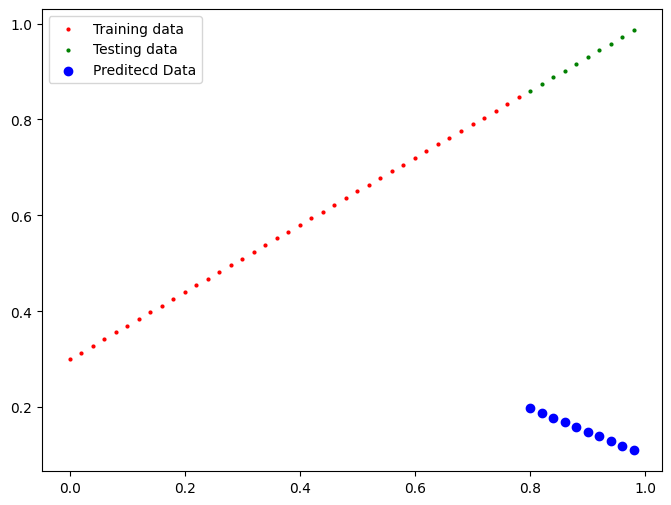

In [29]:
plot_train_test_data(prediction=y_preds)